LSTM model with 7 feature ('Log_OC_Ratio', 'Log_HL_Ratio', 'Log_Vol_Change', 'SMA_10','RSI_14', 'ATR_14') + Financial News Sentiment

Target: Log Returns

Last trained on 21-02-2025

Importing all the necessary Libraries 

In [2]:
# Standard library
import os
import random
from datetime import datetime, timedelta

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning preprocessing and metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import ta
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange

# Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [3]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

In [4]:
#Loading the sentiment CSV file before passing it to the LSTM
sentiment_df = pd.read_csv("daily_apple_news_sentiment.csv")

#Converts the date column into a proper datetime object
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

Function to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [5]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end="2026-02-21")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

# Flatten the column names if they're MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

#Calculating Ratios from Stationary Price Features
data['Log_OC_Ratio'] = np.log(data['Close'] / data['Open'])
data['Log_HL_Ratio'] = np.log(data['High'] / data['Low'])
data['Log_Vol_Change'] = np.log(data['Volume'] / data['Volume'].shift(1))

#Trend Indicator
sma10 = SMAIndicator(data['Close'], window=10).sma_indicator()
data['SMA_10'] = data['Close'] / sma10

#Momentum Indicator
data['RSI_14'] = RSIIndicator(data['Close'], window=14).rsi()

#Volatility Indicator
atr_val = AverageTrueRange(data['High'], data['Low'], data['Close'], window=14).average_true_range()
data['ATR_14'] = atr_val / data['Close']

#Calculate log returns from yesterday's close to today's close
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))

data.to_csv("Before.csv", index=False)

#Merge sentiment with stock data using left join (add sentiment data where available)
data = data.merge(
    sentiment_df,
    left_on="Date",
    right_on="date",
    how="left"
)

#Add a new column to the original dataframe 
#Not all days have a sentiment value so add a 0 for all missing sentiment days
data["avg_sentiment"] = data["avg_sentiment"].fillna(0)

#The model cannot differentiate between 0 being a sentiment score and 0 being no news 
#so adding a binary column that gives the model context to only look at days with news

#A binary feature that tells the model whether news exists that day
data["has_news"] = (data["avg_sentiment"] != 0).astype(int)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(method='ffill', inplace=True) 
data.dropna(inplace=True)  

#Shift the returns UP so that today's row contains the value we want to predict (tomorrow)
data['Target'] = data['Log_Returns'].shift(-1) 

data = data.iloc[:-1].reset_index(drop=True)

data.to_csv("After.csv", index=False)

#Define feature 
price_features  = ['Log_OC_Ratio', 'Log_HL_Ratio', 'Log_Vol_Change', 'SMA_10', 'RSI_14', 'ATR_14']
sentiment_features  = ['avg_sentiment', 'has_news']

#Extract specific columns from your DataFrame and converts them into a NumPy array.
price_data = data[price_features].values
sentiment_data = data[sentiment_features].values
target_data = data['Target'].values
datetime_index = data['Date'].values

[*********************100%***********************]  1 of 1 completed
C:\Users\shrav\AppData\Local\Temp\ipykernel_32804\2374077109.py:52: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [6]:
# Get the number of close prices
print(f"Number of close prices: {len(data)}")

Number of close prices: 2786


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [7]:
total_size = len(data)

train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

#Split Price Data (for scaling)
train_price = price_data[:train_size]
val_price = price_data[train_size:train_size + val_size]
test_price = price_data[train_size + val_size:]

#Split Sentiment Data (bianry range so no scaling needed)
train_sent = sentiment_data[:train_size]
val_sent = sentiment_data[train_size:train_size + val_size]
test_sent = sentiment_data[train_size + val_size:]

#Split the Traget (no scaling)
train_y = target_data[:train_size]
val_y   = target_data[train_size:train_size+val_size]
test_y  = target_data[train_size+val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_y)} samples ({len(train_y)/total_size:.2%})")
print(f"Validation set : {len(val_y)} samples ({len(val_y)/total_size:.2%})")
print(f"Test set       : {len(test_y)} samples ({len(test_y)/total_size:.2%})")

print("Train:", train_y.shape)
print("Val  :", val_y.shape)
print("Test :", test_y.shape)

print("\nCheck sum:", len(train_y) + len(val_y) + len(test_y))

Total samples: 2786

Dataset sizes:
Training set   : 1950 samples (69.99%)
Validation set : 417 samples (14.97%)
Test set       : 419 samples (15.04%)
Train: (1950,)
Val  : (417,)
Test : (419,)

Check sum: 2786


Normalizing the price features using a Standard Scaler. But only using only the training data as the scaler to prevent data leaks. 

In [8]:
#We are now scaling the data feature wise to ensure all features contribute meaningfully
num_features = train_price.shape[1]
scalers = [StandardScaler() for _ in range(num_features)]

#Fit scalers on training data only
for i, scaler in enumerate(scalers):
    scaler.fit(train_price[:, [i]])

#Function to scale data using all scalers
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#Transform all splits
train_price_scaled = scale_data(train_price, scalers)
val_price_scaled = scale_data(val_price, scalers)
test_price_scaled = scale_data(test_price, scalers)

# Training data Mean should be ~0 and Std Dev should be ~1
print(f"Train Scaled -> Mean: {train_price_scaled.mean():.4f}, Std Dev: {train_price_scaled.std():.4f}")
# Val/Test will vary slightly, which is expected
print(f"Val   Scaled -> Mean: {val_price_scaled.mean():.4f}, Std Dev: {val_price_scaled.std():.4f}")
print(f"Test  Scaled -> Mean: {test_price_scaled.mean():.4f}, Std Dev: {test_price_scaled.std():.4f}")

Train Scaled -> Mean: -0.0000, Std Dev: 1.0000
Val   Scaled -> Mean: -0.0708, Std Dev: 0.8663
Test  Scaled -> Mean: -0.0027, Std Dev: 1.0327


In [ ]:
#Stack scaled prices with unscaled sentiment
train_final = np.hstack([train_price_scaled, train_sent])
val_final = np.hstack([val_price_scaled, val_sent])
test_final = np.hstack([test_price_scaled, test_sent])

all_cols = price_features + sentiment_features

datasets = {
    "Train": train_final,
    "Validation": val_final,
    "Test": test_final
}

#Loop through the dictionary items
for name, data in datasets.items():
    rows, cols = data.shape
    print(f"{name} Set - Rows: {rows}, Columns: {cols}")

Train Set - Rows: 1950, Columns: 8
Validation Set - Rows: 417, Columns: 8
Test Set - Rows: 419, Columns: 8


Creating a Sliding Window to prepare the input data for the LSTM model

In [10]:
def create_multifeature_dataset_with_context(feature_data, target_data, time_step, prev_features=None):
    #Handling context for the validation and test set (stacking the last 24 days from the previous set to the current set)
    if prev_features is not None:
        feature_data = np.vstack([prev_features[-(time_step - 1):], feature_data])
    
    X, y = [] , []
    
    for i in range(time_step - 1, len(feature_data)):
        window = feature_data[i - (time_step - 1) : i + 1] #here we grab all columns and rows per timesteps (rows 0-24 first time)
        X.append(window)
        
        if prev_features is not None:
            y_idx = i - (time_step - 1) #here we predict the target for row 25

        #For the validation and test set we stacked the last 24 days from the previous set to the current set 
        #so to ensure the target (first index in the validation or test set) is aligned we need to use index 24
        else:
            y_idx = i  
            
        if y_idx < len(target_data):
            y.append(target_data[y_idx])
    
    return np.array(X), np.array(y)

time_step = 25

X_train, y_train = create_multifeature_dataset_with_context(train_final, train_y, time_step)

X_val, y_val = create_multifeature_dataset_with_context(val_final, val_y, time_step, prev_features=train_final)

X_test, y_test = create_multifeature_dataset_with_context(test_final, test_y, time_step, prev_features=val_final)

# Check shapes
print("Shapes of the datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

Shapes of the datasets:
X_train: (1926, 25, 8), y_train: (1926,)
X_val  : (417, 25, 8), y_val  : (417,)
X_test : (419, 25, 8), y_test : (419,)


Building and Training the model

In [11]:
model = Sequential()

#Build the model

#layer 1
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add((LSTM(units=64, return_sequences=True)))
model.add((LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.1))

model.add(Dense(units=1))

#compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mean_squared_error', metrics=['MAE'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          
    patience=3,          
    verbose=1,  
    min_lr=1e-6         
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=150,
    batch_size=32,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - MAE: 0.0481 - loss: 0.0042 - val_MAE: 0.0237 - val_loss: 9.2673e-04 - learning_rate: 0.0010
Epoch 2/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - MAE: 0.0283 - loss: 0.0017 - val_MAE: 0.0163 - val_loss: 4.5168e-04 - learning_rate: 0.0010
Epoch 3/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.0259 - loss: 0.0013 - val_MAE: 0.0179 - val_loss: 5.6694e-04 - learning_rate: 0.0010
Epoch 4/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.0205 - loss: 7.6852e-04 - val_MAE: 0.0137 - val_loss: 3.3669e-04 - learning_rate: 0.0010
Epoch 5/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.0178 - loss: 5.9226e-04 - val_MAE: 0.0132 - val_loss: 3.1383e-04 - learning_rate: 0.0010
Epoch 6/150
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - MAE: 0.0161 - loss: 4.8314e-04 - val_MAE: 0.0129 - val_loss: 3.0423e-04 - learning_rate: 0.0010
Epoch 7/150
57/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MAE: 0.0142 - loss: 3.6625e-04
Epoch 7: ReduceLROnPlateau reduc

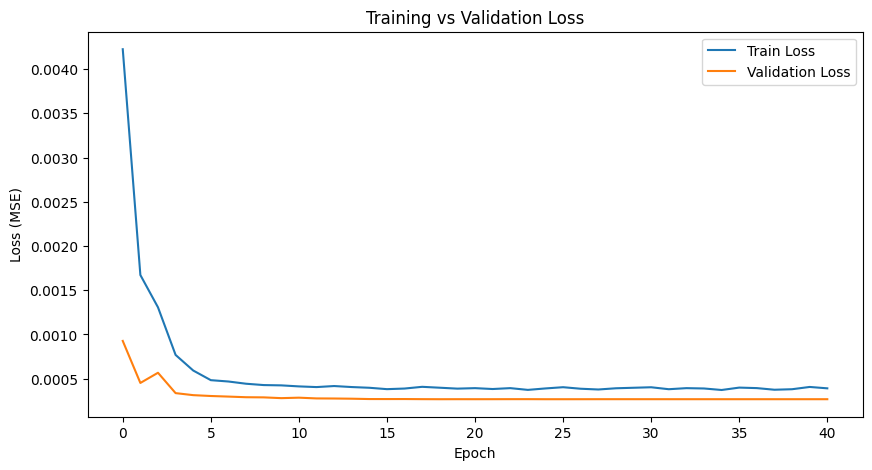

In [ ]:
#Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predictions

In [13]:
#Generate predictions (raw log returns)
predictions = model.predict(X_test)

#Flatten to a 1D array for easier handling
predictions_flat = predictions.flatten()

#Ensure y_test is also flattened for comparison
actual_flat = y_test.flatten()

mse = mean_squared_error(actual_flat, predictions_flat)
mae = mean_absolute_error(actual_flat, predictions_flat)

print(f"--- Test Metrics ---")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
--- Test Metrics ---
MSE: 0.000340
MAE: 0.012661


In [14]:
#Extract the actual log returns for the test period
actual_returns = y_test.flatten()
predicted_returns = predictions.flatten()

#Determine the direction (1 for Up, 0 for Down/Flat)
actual_dir = (actual_returns > 0).astype(int)
pred_dir = (predicted_returns > 0).astype(int)

#Calculate Accuracy
correct_predictions = (actual_dir == pred_dir)
accuracy = np.mean(correct_predictions)

print(f"--- Directional Statistics ---")
print(f"Total Test Days: {len(actual_dir)}")
print(f"Correct Directional Predictions: {np.sum(correct_predictions)}")
print(f"Directional Accuracy (Hit Rate): {accuracy:.2%}")

--- Directional Statistics ---
Total Test Days: 419
Correct Directional Predictions: 219
Directional Accuracy (Hit Rate): 52.27%


In [ ]:
#Naïve Baseline: Predicting 0 for every day
baseline_preds = np.zeros_like(actual_flat)

baseline_mse = mean_squared_error(actual_flat, baseline_preds)
baseline_mae = mean_absolute_error(actual_flat, baseline_preds)

print(f"--- Naïve Baseline (Predict 0) ---")
print(f"Baseline MSE: {baseline_mse:.6f}")
print(f"Baseline MAE: {baseline_mae:.6f}")

#Model vs Baseline Comparison
mse_improvement = (baseline_mse - mse) / baseline_mse
mae_improvement = (baseline_mae - mae) / baseline_mae

print(f"\n--- Model Value Analysis ---")
print(f"MSE vs Baseline: {'BETTER' if mse < baseline_mse else 'WORSE'} ({mse_improvement:.2%})")
print(f"MAE vs Baseline: {'BETTER' if mae < baseline_mae else 'WORSE'} ({mae_improvement:.2%})")

#Directional Baseline: Always guessing the majority direction
up_day_ratio = np.mean(actual_returns > 0)
majority_class_baseline = max(up_day_ratio, 1 - up_day_ratio)

print(f"\n--- Directional Accuracy Baseline ---")
print(f"Buy & Hold (Always Up) Accuracy: {up_day_ratio:.2%}")
print(f"Majority Class Baseline: {majority_class_baseline:.2%}")
print(f"Model Hit Rate: {accuracy:.2%}")
print(f"Value Add: {'YES' if accuracy > majority_class_baseline else 'NO'}")

--- Naïve Baseline (Predict 0) ---
Baseline MSE: 0.000325
Baseline MAE: 0.011797

--- Model Value Analysis ---
MSE vs Baseline: WORSE (-4.87%)
MAE vs Baseline: WORSE (-7.32%)

--- Directional Accuracy Baseline ---
Buy & Hold (Always Up) Accuracy: 54.89%
Majority Class Baseline: 54.89%
Model Hit Rate: 52.27%
Value Add: NO
